# Generación y Validación de la Matriz de Vecindad Distrital

**Objetivo:** Construir una matriz de adyacencia espacial (vecinos) para los 1891 distritos del Perú, integrando geometría oficial y datos socioeconómicos.

**Metodología:**
1.  **Evaluación de Fuentes:** Comparación de geometrías (Shapefile vs GeoJSON vs Excel).
2.  **Fusión de Datos (Merge):** Integración de la geometría ganadora con indicadores socioeconómicos (NBI, Agua, Electricidad) del INEI/GeoPeru.
3.  **Definición de Vecindad:** Cálculo de contigüidad física (Criterio Queen).
4.  **Corrección Topológica:** Identificación y conexión artificial de "islas" (distritos sin vecinos físicos) mediante KNN.
5.  **Validación Estadística:** Análisis de conectividad y cobertura de datos.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import libpysal
from libpysal.weights import Queen, KNN
from shapely import wkt
import os
import warnings

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print(f"Librerías importadas. GeoPandas versión: {gpd.__version__}")

c:\Users\Alvaro\anaconda3\envs\modelos_fisio_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Librerías importadas. GeoPandas versión: 1.1.1


## 1. Carga y Estandarización de Datos Maestros
Cargamos el archivo de referencia que contiene los códigos UBIGEO oficiales y datos aumentados para asegurar la integridad de los IDs.

In [2]:
# Ruta a tu CSV aumentado
path_ref = 'ubigeo_distrito.csv'

# Cargar asegurando que el UBIGEO sea string de 6 dígitos
df_ref = pd.read_csv(path_ref, dtype={'inei': str, 'reniec': str})
df_ref.rename(columns={'inei': 'UBIGEO'}, inplace=True)
df_ref['UBIGEO'] = df_ref['UBIGEO'].str.zfill(6)

print(f"Referencias cargadas: {df_ref.shape}")

Referencias cargadas: (1893, 20)


## 2. Evaluación y Selección de Fuentes Geográficas
Cargamos tres fuentes potenciales (Shapefile de GeoGPS, GeoJSON de GitHub y Excel de GeoPeru) para determinar cuál ofrece la mejor geometría y cobertura.

In [3]:
# --- 1. Cargar Shapefile (GeoGPSPeru) ---
path_shp = 'shapefiles geogpsperu/Distrital INEI 2023 geogpsperu SuyoPomalia.shp'
try:
    gdf_shp = gpd.read_file(path_shp)
    # Estandarizar UBIGEO
    col_ubigeo_shp = 'UBIGEO' 
    if col_ubigeo_shp in gdf_shp.columns:
        gdf_shp[col_ubigeo_shp] = gdf_shp[col_ubigeo_shp].astype(str).str.zfill(6)
    print(f"SHP GeoGPS cargado: {len(gdf_shp)} polígonos")
except Exception as e:
    print(f"Error SHP: {e}")
    gdf_shp = None

# --- 2. Cargar GeoJSON (Github) ---
path_geojson = 'geojson GitHub/peru_distrital_simple.geojson'
try:
    gdf_json = gpd.read_file(path_geojson)
    col_ubigeo_json = 'IDDIST' if 'IDDIST' in gdf_json.columns else 'UBIGEO'
    gdf_json[col_ubigeo_json] = gdf_json[col_ubigeo_json].astype(str).str.zfill(6)
    print(f"GeoJSON Github cargado: {len(gdf_json)} polígonos")
except Exception as e:
    print(f"Error GeoJSON: {e}")
    gdf_json = None

# --- 3. Cargar Excel con Datos (GeoPeru) ---
path_excel = 'csv geoperu/GeoPeru-peru_distritos.xlsx'
try:
    df_excel = pd.read_excel(path_excel)
    # Buscar columna UBIGEO
    posibles_cols = ['ubigeo', 'cod_dist', 'id_distrito']
    col_ubigeo_excel = next((c for c in posibles_cols if c in df_excel.columns), None)
    
    if col_ubigeo_excel:
        df_excel[col_ubigeo_excel] = df_excel[col_ubigeo_excel].astype(str).str.zfill(6)
        print(f"Excel GeoPeru cargado: {len(df_excel)} registros (Columna: {col_ubigeo_excel})")
    else:
        print("Error: No se encontró columna UBIGEO en el Excel.")
except Exception as e:
    print(f"Error Excel: {e}")
    df_excel = None

SHP GeoGPS cargado: 1891 polígonos
GeoJSON Github cargado: 1834 polígonos
Excel GeoPeru cargado: 1874 registros (Columna: cod_dist)


## 3. Fusión de Datos (Merge)
Seleccionamos el **Shapefile de GeoGPS** por ser el más completo y lo enriquecemos con las variables socioeconómicas del Excel de GeoPeru.
*   **Geometría:** GeoGPSPeru (2023).
*   **Datos:** GeoPeru (NBI, Agua, Electricidad).

In [4]:
# 1. Preparar Datos Socioeconómicos
df_excel_limpio = df_excel.rename(columns={col_ubigeo_excel: 'UBIGEO'})

# Seleccionar columnas clave disponibles
columnas_interes = [
    'UBIGEO', 'nom_dist', 'pob_total', 
    'nbi1_porc',   # Vivienda inadecuada
    'pvs_agua_r',  # % Agua Red Pública
    'pvs_aelec'    # % Electricidad
]
cols_finales = [c for c in columnas_interes if c in df_excel_limpio.columns]
df_datos_socio = df_excel_limpio[cols_finales].copy()

# 2. Fusión (Left Join para preservar el mapa)
gdf_final = gdf_shp.merge(df_datos_socio, on='UBIGEO', how='left')

# 3. Limpieza Topológica
gdf_final['geometry'] = gdf_final.geometry.buffer(0)

print(f"GeoDataFrame Final Integrado: {gdf_final.shape}")
print(f"Variables disponibles: {gdf_final.columns.tolist()}")

GeoDataFrame Final Integrado: (1891, 15)
Variables disponibles: ['UBIGEO', 'CCDD', 'CCPP', 'CCDI', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'OBJECTID', 'ESRI_OID', 'geometry', 'nom_dist', 'pob_total', 'nbi1_porc', 'pvs_agua_r', 'pvs_aelec']


## 4. Generación de Matriz de Vecindad y Corrección de Islas
Calculamos la contigüidad espacial (Criterio Queen). Identificamos distritos aislados (islas reales o errores) y los conectamos artificialmente a su vecino más cercano (KNN=1) para garantizar la viabilidad del modelo INLA.

In [5]:
print("Calculando vecinos (Queen Contiguity)...")
w_queen = Queen.from_dataframe(gdf_final, ids='UBIGEO')

# --- Detección y Corrección de Islas ---
islas = w_queen.islands
print(f"Islas detectadas inicialmente: {len(islas)} -> {islas}")

if len(islas) > 0:
    print("Aplicando corrección KNN=1 para islas...")
    # Calcular vecino más cercano por distancia para TODOS
    w_knn = KNN.from_dataframe(gdf_final, k=1, ids='UBIGEO')
    
    for isla in islas:
        if isla in w_knn.neighbors:
            vecino_cercano = w_knn.neighbors[isla][0]
            # Conectar manualmente en la matriz Queen
            w_queen.neighbors[isla].append(vecino_cercano)
            w_queen.neighbors[vecino_cercano].append(isla)
            # Actualizar pesos internos
            w_queen.weights[isla].append(1.0)
            w_queen.weights[vecino_cercano].append(1.0)
            print(f" -> Isla {isla} conectada a {vecino_cercano}")

    # Recalcular cache de islas para confirmar
    print(f"Islas restantes: {len(w_queen.islands)}")
else:
    print("No se requieren correcciones.")

Calculando vecinos (Queen Contiguity)...
Islas detectadas inicialmente: 2 -> ['210103', '211302']
Aplicando corrección KNN=1 para islas...
 -> Isla 210103 conectada a 210105
 -> Isla 211302 conectada a 211307
Islas restantes: 2


### Validación Visual de la Corrección
Visualizamos las conexiones artificiales creadas para las islas (Amantaní y Anapia) para asegurar que tengan sentido lógico/geográfico.

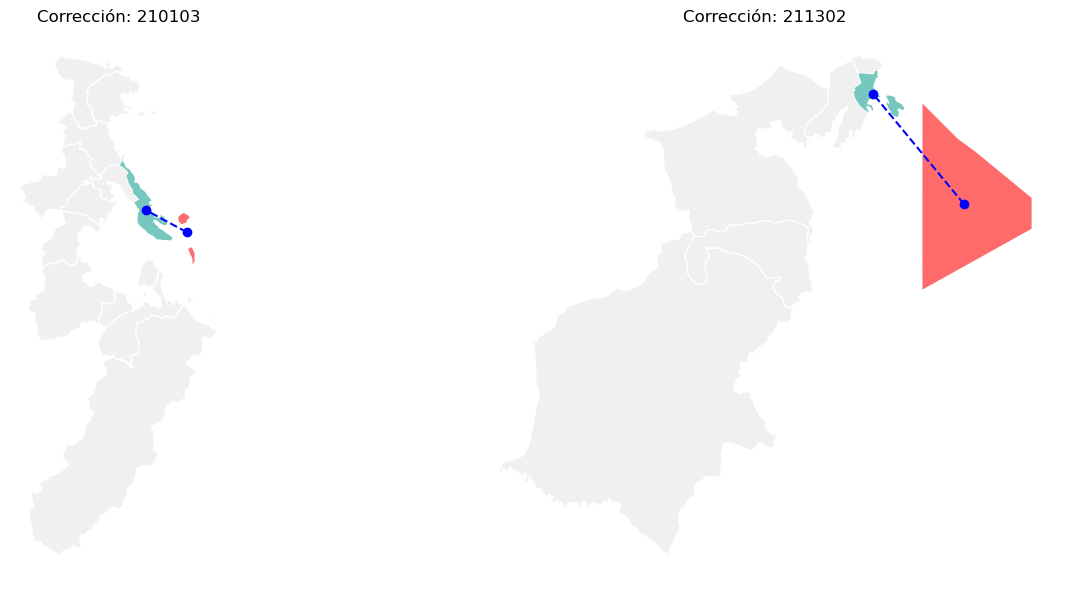

In [6]:
islas_a_verificar = ['210103', '211302'] # Amantaní y Anapia
fig, axes = plt.subplots(1, len(islas_a_verificar), figsize=(15, 6))
if len(islas_a_verificar) == 1: axes = [axes]

for i, ubigeo in enumerate(islas_a_verificar):
    ax = axes[i]
    gdf_isla = gdf_final[gdf_final['UBIGEO'] == ubigeo]
    
    if ubigeo in w_queen.neighbors:
        vecinos = w_queen.neighbors[ubigeo]
        gdf_vecinos = gdf_final[gdf_final['UBIGEO'].isin(vecinos)]
        
        # Zoom
        bounds = pd.concat([gdf_isla, gdf_vecinos]).total_bounds
        m = 0.1
        gdf_ctx = gdf_final.cx[bounds[0]-m:bounds[2]+m, bounds[1]-m:bounds[3]+m]
        
        gdf_ctx.plot(ax=ax, color='#f0f0f0', edgecolor='white')
        gdf_vecinos.plot(ax=ax, color='#76c7c0', label='Vecino Asignado')
        gdf_isla.plot(ax=ax, color='#ff6b6b', label='Isla')
        
        # Línea de conexión
        c_isla = gdf_isla.geometry.centroid.iloc[0]
        c_vecino = gdf_vecinos.geometry.centroid.iloc[0]
        ax.plot([c_isla.x, c_vecino.x], [c_isla.y, c_vecino.y], 'b--', marker='o')
        
        ax.set_title(f"Corrección: {ubigeo}")
        ax.axis('off')

plt.tight_layout()
plt.show()

### Inspección de Casos Especiales (Distritos con 1 solo vecino)
Verificamos casos como "La Punta" o zonas fronterizas que, aunque no son islas, tienen una conectividad muy baja. Esto es válido matemáticamente pero bueno de confirmar visualmente.

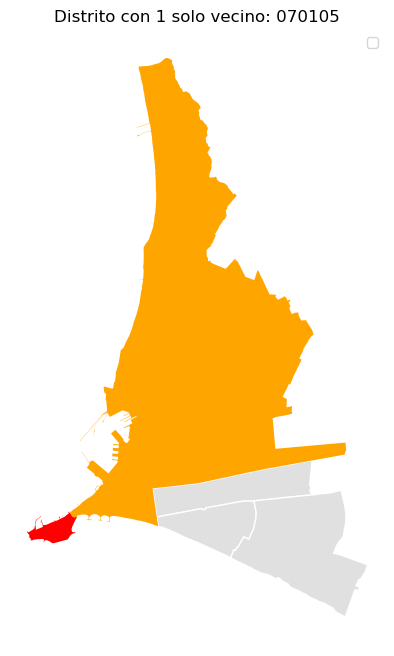

In [7]:
cards = pd.Series(w_queen.cardinalities)
un_vecino = cards[cards == 1].index.tolist()

if len(un_vecino) > 0:
    target = un_vecino[0] # Tomamos el primero (ej. La Punta)
    gdf_target = gdf_final[gdf_final['UBIGEO'] == target]
    gdf_vecino = gdf_final[gdf_final['UBIGEO'] == w_queen.neighbors[target][0]]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    bounds = gdf_target.total_bounds
    m = 0.05
    gdf_final.cx[bounds[0]-m:bounds[2]+m, bounds[1]-m:bounds[3]+m].plot(ax=ax, color='#e0e0e0', edgecolor='white')
    gdf_vecino.plot(ax=ax, color='orange', label='Único Vecino')
    gdf_target.plot(ax=ax, color='red', label='Distrito (1 conexión)')
    
    plt.title(f"Distrito con 1 solo vecino: {target}")
    plt.legend()
    plt.axis('off')
    plt.show()